# 🦴 OsteoDetect — AI-Based Bone Fracture Detection
### CNN (ResNet-50) on GRAZPEDWRI-DX Dataset

## ⚠️ HOW TO USE THIS NOTEBOOK

**Step 1:** Go to → https://www.kaggle.com/datasets/banuprasadb/grazpedwri-dx  
**Step 2:** Click **'New Notebook'** button on the right side  
**Step 3:** In the notebook → go to **Settings (right panel) → Accelerator → GPU P100**  
**Step 4:** Upload this file via **File → Import Notebook**  
**Step 5:** Run all cells — dataset is already mounted, NO downloading needed!

---
**Dataset:** GRAZPEDWRI-DX (20,327 pediatric wrist X-rays)  
**Model:** ResNet-50 Transfer Learning  
**Task:** Binary Classification — Fractured vs Normal

## Cell 1 — Check Dataset is Mounted

In [7]:
import os
print(os.listdir('/kaggle/input/datasets/banuprasadb'))

['grazpedwri-dx']


In [8]:
import os

# ✅ Updated correct path (based on your structure)
BASE = '/kaggle/input/datasets/banuprasadb/grazpedwri-dx'

# Check structure
print("Dataset folders:")
for item in os.listdir(BASE):
    print(item)

print("\nImage counts:")

# Count images
for split in ['train', 'valid', 'test']:
    path = f'{BASE}/{split}/images'
    
    if os.path.exists(path):
        print(f'{split}/images: {len(os.listdir(path))} images')
    else:
        print(f'{split}/images: ❌ Not found')

Dataset folders:
data.yaml
valid
test
train

Image counts:
train/images: 16261 images
valid/images: 2032 images
test/images: 2034 images


## Cell 2 — Read Class Names from data.yaml

In [9]:
# Read class names
with open(f'{BASE}/data.yaml', 'r') as f:
    print(f.read())

# Class names in order:
# 0=boneanomaly, 1=bonelesion, 2=foreignbody, 3=fracture,
# 4=metal, 5=periostealreaction, 6=pronatorsign, 7=softtissue, 8=text
# We will use class 3 = fracture for binary classification

train: ../train/images  
val: ../valid/images    
test: ../test/images  
nc: 9
names: ["boneanomaly","bonelesion","foreignbody","fracture","metal","periostealreaction","pronatorsign","softtissue","text"]


## Cell 3 — Organize Dataset into Fracture / Normal Folders

In [10]:
import os, shutil
from tqdm import tqdm

FRACTURE_CLASS = '3'  # fracture is class index 3
OUTPUT = '/kaggle/working/graz_binary'

def organize_dataset(split_name, source_images, source_labels, output_base):
    frac_dir = f'{output_base}/{split_name}/fractured'
    norm_dir = f'{output_base}/{split_name}/normal'
    os.makedirs(frac_dir, exist_ok=True)
    os.makedirs(norm_dir, exist_ok=True)

    fractured, normal = 0, 0

    for label_file in tqdm(os.listdir(source_labels), desc=split_name):
        if not label_file.endswith('.txt'):
            continue
        label_path = f'{source_labels}/{label_file}'
        # Try png then jpg
        image_name = label_file.replace('.txt', '.png')
        image_path = f'{source_images}/{image_name}'
        if not os.path.exists(image_path):
            image_name = label_file.replace('.txt', '.jpg')
            image_path = f'{source_images}/{image_name}'
        if not os.path.exists(image_path):
            continue

        has_fracture = False
        with open(label_path, 'r') as f:
            for line in f:
                if line.strip() and line.strip().split()[0] == FRACTURE_CLASS:
                    has_fracture = True
                    break

        if has_fracture:
            shutil.copy(image_path, frac_dir)
            fractured += 1
        else:
            shutil.copy(image_path, norm_dir)
            normal += 1

    print(f'{split_name} → fractured: {fractured}, normal: {normal}')
    return fractured, normal

# Organize all splits
tf, tn = organize_dataset('train', f'{BASE}/train/images', f'{BASE}/train/labels', OUTPUT)
vf, vn = organize_dataset('valid', f'{BASE}/valid/images', f'{BASE}/valid/labels', OUTPUT)
ef, en = organize_dataset('test',  f'{BASE}/test/images',  f'{BASE}/test/labels',  OUTPUT)

print(f'\nTotal: {tf+vf+ef} fractured, {tn+vn+en} normal')
print('Dataset organized!')

train: 100%|██████████| 16261/16261 [04:44<00:00, 57.09it/s]


train → fractured: 10842, normal: 5419


valid: 100%|██████████| 2032/2032 [00:32<00:00, 62.05it/s]


valid → fractured: 1366, normal: 666


test: 100%|██████████| 2034/2034 [00:34<00:00, 58.13it/s]

test → fractured: 1342, normal: 692

Total: 13550 fractured, 6777 normal
Dataset organized!


## Cell 4 — Setup Data Generators

In [11]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

OUTPUT = '/kaggle/working/graz_binary'

tf.keras.backend.clear_session()

# ====== DATA GENERATORS (FIXED) ======
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# ====== LOAD DATA ======
train_gen = train_datagen.flow_from_directory(
    f'{OUTPUT}/train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

val_gen = val_datagen.flow_from_directory(
    f'{OUTPUT}/valid',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

test_gen = val_datagen.flow_from_directory(
    f'{OUTPUT}/test',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

# ====== CLASS WEIGHTS ======
import numpy as np
train_labels = train_gen.classes

fracture_count = np.sum(train_labels == 0)
normal_count = np.sum(train_labels == 1)

total = fracture_count + normal_count

class_weights = {
    0: total / (2 * fracture_count),
    1: total / (2 * normal_count)
}

print("✅ Generators fixed")

Found 16261 images belonging to 2 classes.
Found 2032 images belonging to 2 classes.
Found 2034 images belonging to 2 classes.
✅ Generators fixed


## Cell 5 — Build ResNet-50 Model

In [12]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, Model

base = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base.trainable = False

x = layers.GlobalAveragePooling2D()(base.output)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(1, activation='sigmoid')(x)

model = Model(inputs=base.input, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

print(f'Total params: {model.count_params():,}')
print(f'Trainable params: {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}')

Total params: 24,129,793
Trainable params: 541,569


## Cell 6 — Phase 1 Training (Frozen Base)

In [13]:
print('--- Phase 1: Training top layers (base frozen) ---')
import tensorflow as tf
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath='/kaggle/working/best_phase1_model.keras',
    monitor='val_auc',
    mode='max',
    save_best_only=True,
    verbose=1
)

history1 = model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    class_weight=class_weights,
    callbacks=[
        checkpoint,  # ✅ added this
        tf.keras.callbacks.EarlyStopping(
            patience=3,
            restore_best_weights=True,
            monitor='val_auc',
            mode='max'
        )
    ]
)

print(f"\nBest val_accuracy: {max(history1.history['val_accuracy']):.4f}")
print(f"Best val_auc: {max(history1.history['val_auc']):.4f}")

--- Phase 1: Training top layers (base frozen) ---


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1776854727.064342     125 service.cc:152] XLA service 0x7eb148001f30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776854727.064408     125 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1776854729.524873     125 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/509 ━━━━━━━━━━━━━━━━━━━━ 30s 60ms/step - accuracy: 0.5078 - auc: 0.4648 - loss: 1.0650   

I0000 00:00:1776854735.262702     125 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


509/509 ━━━━━━━━━━━━━━━━━━━━ 0s 821ms/step - accuracy: 0.5233 - auc: 0.5507 - loss: 0.8974
Epoch 1: val_auc improved from -inf to 0.58704, saving model to /kaggle/working/best_phase1_model.keras
509/509 ━━━━━━━━━━━━━━━━━━━━ 477s 905ms/step - accuracy: 0.5233 - auc: 0.5507 - loss: 0.8973 - val_accuracy: 0.6280 - val_auc: 0.5870 - val_loss: 0.6272
Epoch 2/10
509/509 ━━━━━━━━━━━━━━━━━━━━ 0s 720ms/step - accuracy: 0.5341 - auc: 0.5722 - loss: 0.7755
Epoch 2: val_auc improved from 0.58704 to 0.59855, saving model to /kaggle/working/best_phase1_model.keras
509/509 ━━━━━━━━━━━━━━━━━━━━ 394s 775ms/step - accuracy: 0.5341 - auc: 0.5722 - loss: 0.7755 - val_accuracy: 0.6127 - val_auc: 0.5986 - val_loss: 0.6345
Epoch 3/10
509/509 ━━━━━━━━━━━━━━━━━━━━ 0s 674ms/step - accuracy: 0.5440 - auc: 0.5765 - loss: 0.7473
Epoch 3: val_auc did not improve from 0.59855
509/509 ━━━━━━━━━━━━━━━━━━━━ 368s 723ms/step - accuracy: 0.5440 - auc: 0.5765 - loss: 0.7473 - val_accuracy: 0.6142 - val_auc: 0.5896 - val_lo

## Cell 7 — Phase 2 Fine-Tuning (Unfreeze Last 20 Layers)

In [14]:
print('--- Phase 2: Fine-tuning last 20 layers ---')

base.trainable = True
for layer in base.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# 🔥 Add checkpoint (VERY IMPORTANT)
checkpoint2 = tf.keras.callbacks.ModelCheckpoint(
    filepath='/kaggle/working/best_phase2_model.keras',
    monitor='val_auc',
    mode='max',
    save_best_only=True,
    verbose=1
)

history2 = model.fit(
    train_gen,
    epochs=5,  # 🔥 reduced (no need 10)
    validation_data=val_gen,
    class_weight=class_weights,
    callbacks=[
        checkpoint2,
        tf.keras.callbacks.EarlyStopping(
            patience=2,
            restore_best_weights=True,
            monitor='val_auc',
            mode='max'
        )
    ]
)

# Optional final save
model.save('/kaggle/working/osteodetect_final.keras')

print('\nModel saved to /kaggle/working/')
print(f"Best val_accuracy: {max(history2.history['val_accuracy']):.4f}")
print(f"Best val_auc: {max(history2.history['val_auc']):.4f}")

--- Phase 2: Fine-tuning last 20 layers ---
Epoch 1/5
509/509 ━━━━━━━━━━━━━━━━━━━━ 0s 638ms/step - accuracy: 0.5297 - auc: 0.5737 - loss: 0.6947
Epoch 1: val_auc improved from -inf to 0.60790, saving model to /kaggle/working/best_phase2_model.keras
509/509 ━━━━━━━━━━━━━━━━━━━━ 376s 706ms/step - accuracy: 0.5297 - auc: 0.5737 - loss: 0.6947 - val_accuracy: 0.5591 - val_auc: 0.6079 - val_loss: 0.6422
Epoch 2/5
509/509 ━━━━━━━━━━━━━━━━━━━━ 0s 638ms/step - accuracy: 0.5361 - auc: 0.5902 - loss: 0.6821
Epoch 2: val_auc improved from 0.60790 to 0.60896, saving model to /kaggle/working/best_phase2_model.keras
509/509 ━━━━━━━━━━━━━━━━━━━━ 351s 689ms/step - accuracy: 0.5360 - auc: 0.5902 - loss: 0.6821 - val_accuracy: 0.5379 - val_auc: 0.6090 - val_loss: 0.6565
Epoch 3/5
509/509 ━━━━━━━━━━━━━━━━━━━━ 0s 639ms/step - accuracy: 0.5317 - auc: 0.5901 - loss: 0.6810
Epoch 3: val_auc improved from 0.60896 to 0.61184, saving model to /kaggle/working/best_phase2_model.keras
509/509 ━━━━━━━━━━━━━━━━━━━━ 

## Cell 8 — Plot Training Curves (Paper Figures)

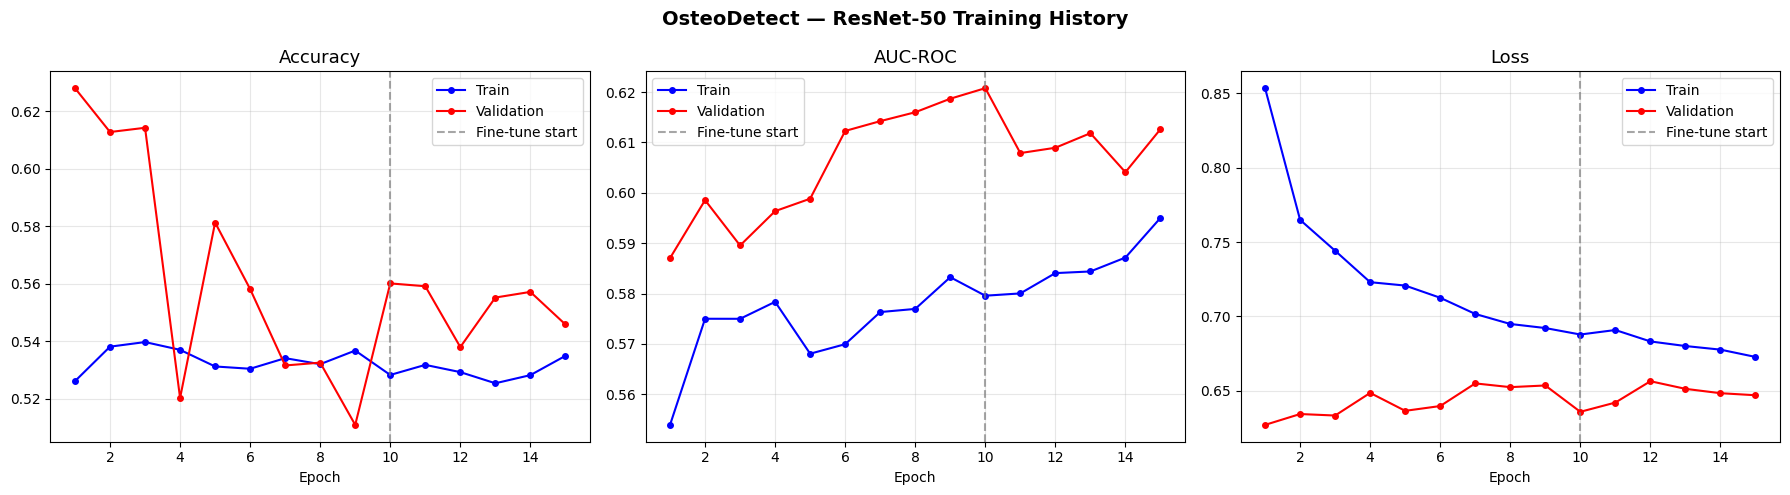

✅ Saved: training_curves.png


In [15]:
import matplotlib.pyplot as plt

# ✅ Safely handle history2 (in case anything missing)
acc      = history1.history['accuracy']     + history2.history.get('accuracy', [])
val_acc  = history1.history['val_accuracy'] + history2.history.get('val_accuracy', [])
auc      = history1.history['auc']          + history2.history.get('auc', [])
val_auc  = history1.history['val_auc']      + history2.history.get('val_auc', [])
loss     = history1.history['loss']         + history2.history.get('loss', [])
val_loss = history1.history['val_loss']     + history2.history.get('val_loss', [])

# Epochs
epochs = range(1, len(acc) + 1)

# Where Phase 2 starts
phase2_start = len(history1.history['accuracy'])

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, train_data, val_data, title in zip(
    axes,
    [acc, auc, loss],
    [val_acc, val_auc, val_loss],
    ['Accuracy', 'AUC-ROC', 'Loss']
):
    ax.plot(epochs, train_data, 'b-o', markersize=4, label='Train')
    ax.plot(epochs, val_data,   'r-o', markersize=4, label='Validation')
    
    # Vertical line where fine-tuning starts
    ax.axvline(x=phase2_start, color='gray', linestyle='--', alpha=0.7, label='Fine-tune start')
    
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('OsteoDetect — ResNet-50 Training History', fontsize=14, fontweight='bold')
plt.tight_layout()

# Save
plt.savefig('/kaggle/working/training_curves.png', dpi=150, bbox_inches='tight')

# Show
plt.show()

print('✅ Saved: training_curves.png')

## Cell 9 — Evaluate on Test Set

Running predictions on test set...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


64/64 ━━━━━━━━━━━━━━━━━━━━ 40s 561ms/step

=== FINAL TEST SET RESULTS ===
              precision    recall  f1-score   support

   Fractured       0.77      0.48      0.59      1342
      Normal       0.42      0.72      0.53       692

    accuracy                           0.56      2034
   macro avg       0.59      0.60      0.56      2034
weighted avg       0.65      0.56      0.57      2034

AUC-ROC Score: 0.6321


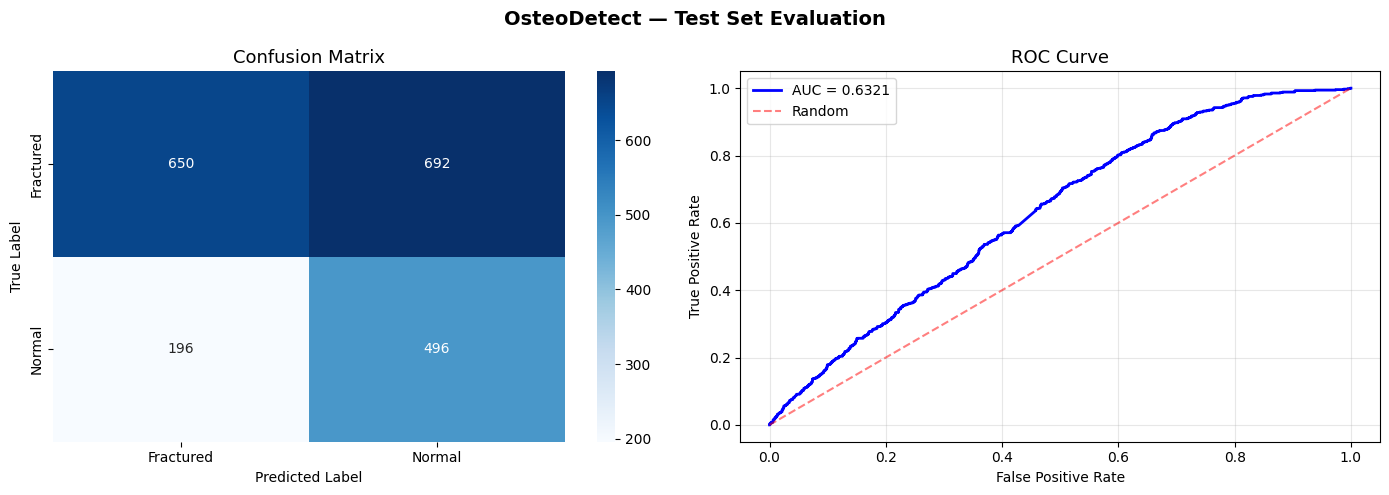

✅ Saved: evaluation.png


In [16]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# 🔥 Fix generator order
test_gen.reset()

# Predictions
print('Running predictions on test set...')
y_pred_prob = model.predict(test_gen, verbose=1)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
y_true = test_gen.classes

# Print metrics
print('\n=== FINAL TEST SET RESULTS ===')
print(classification_report(y_true, y_pred, target_names=['Fractured', 'Normal']))

auc_score = roc_auc_score(y_true, y_pred_prob.flatten())
print(f'AUC-ROC Score: {auc_score:.4f}')

# Confusion Matrix + ROC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Fractured', 'Normal'],
            yticklabels=['Fractured', 'Normal'])
axes[0].set_title('Confusion Matrix', fontsize=13)
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
axes[1].plot(fpr, tpr, 'b-', linewidth=2, label=f'AUC = {auc_score:.4f}')
axes[1].plot([0,1],[0,1], 'r--', alpha=0.5, label='Random')
axes[1].set_title('ROC Curve', fontsize=13)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('OsteoDetect — Test Set Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print('✅ Saved: evaluation.png')

## Cell 10 — Grad-CAM Heatmaps (Explainability)

Using layer: conv5_block3_3_conv
=== FRACTURED ===


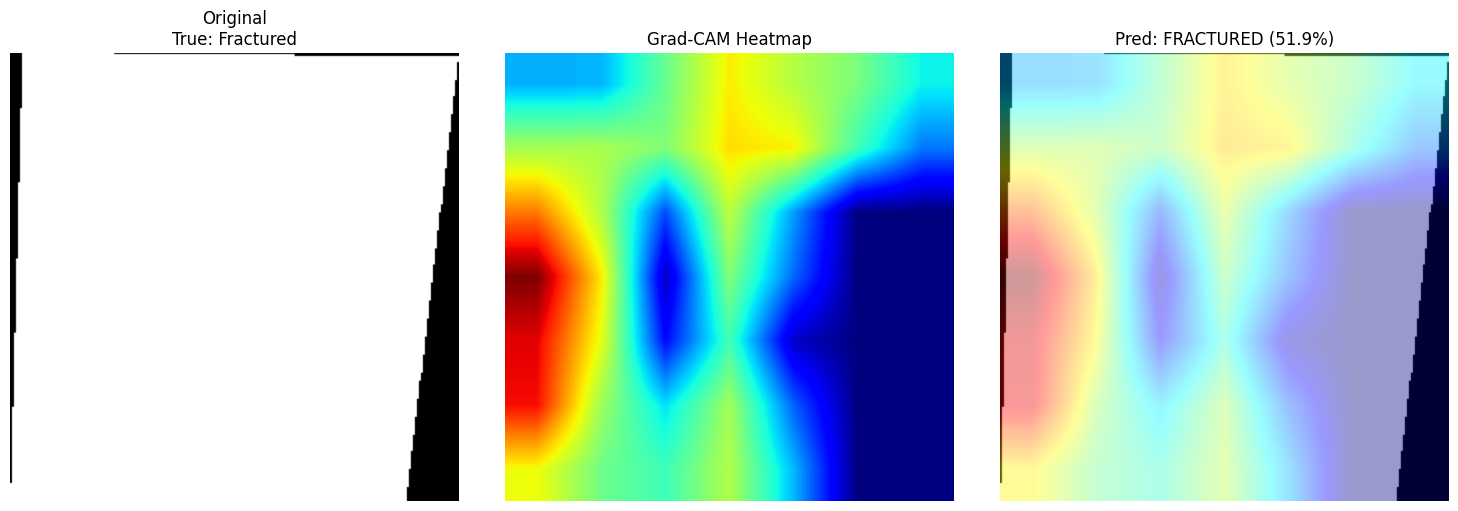

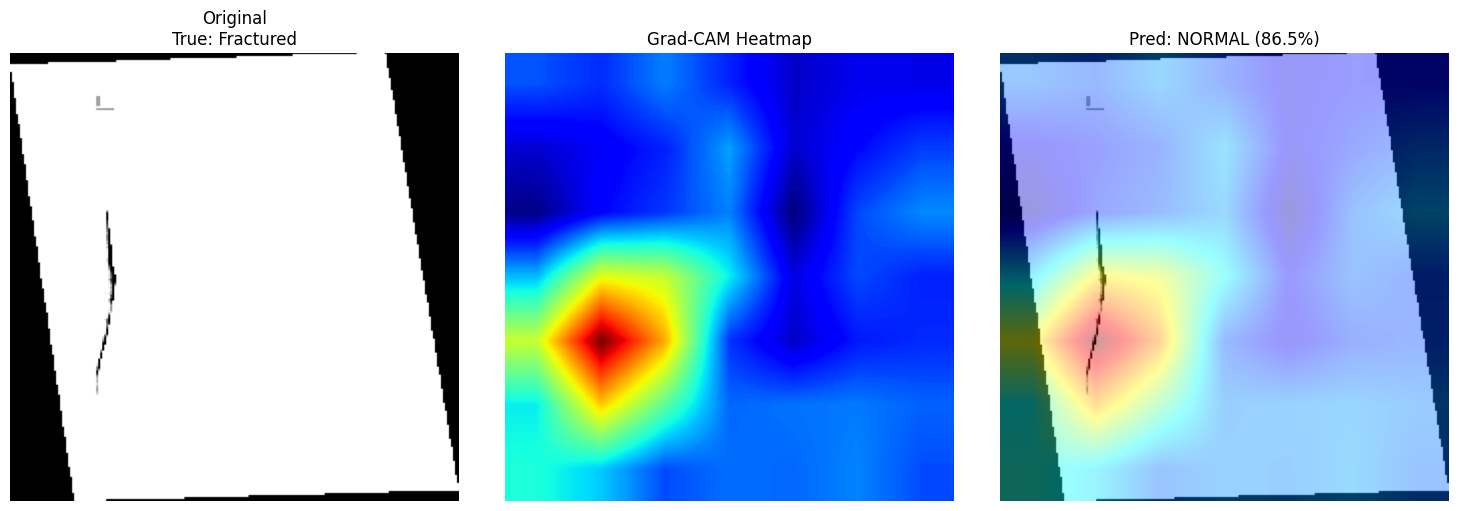

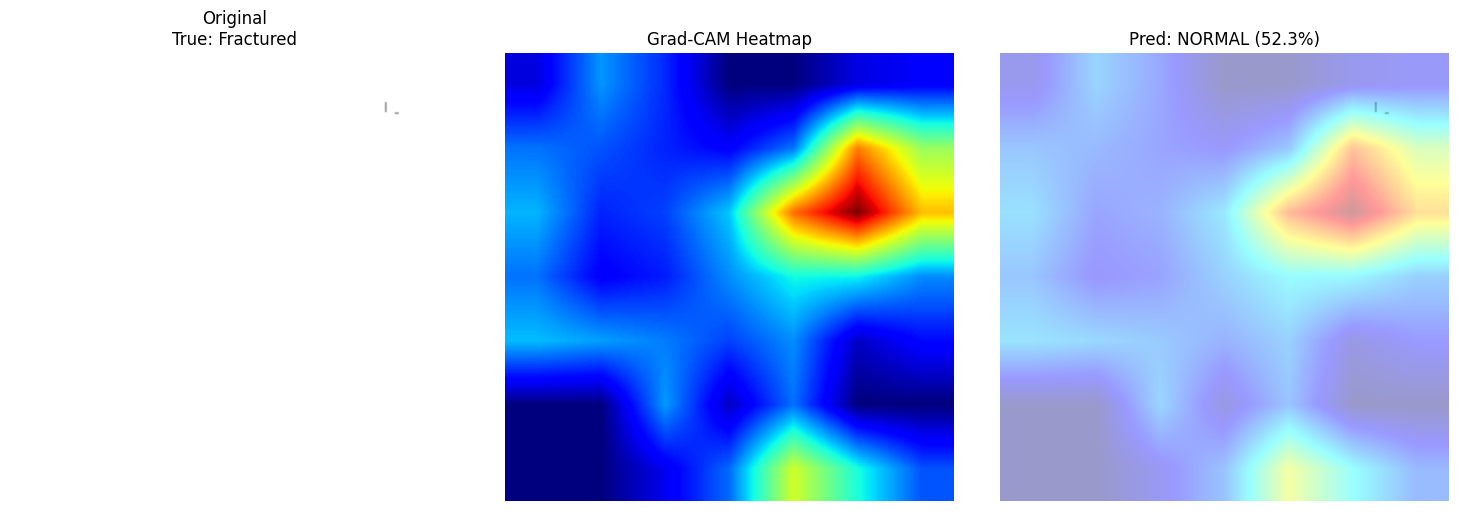


=== NORMAL ===


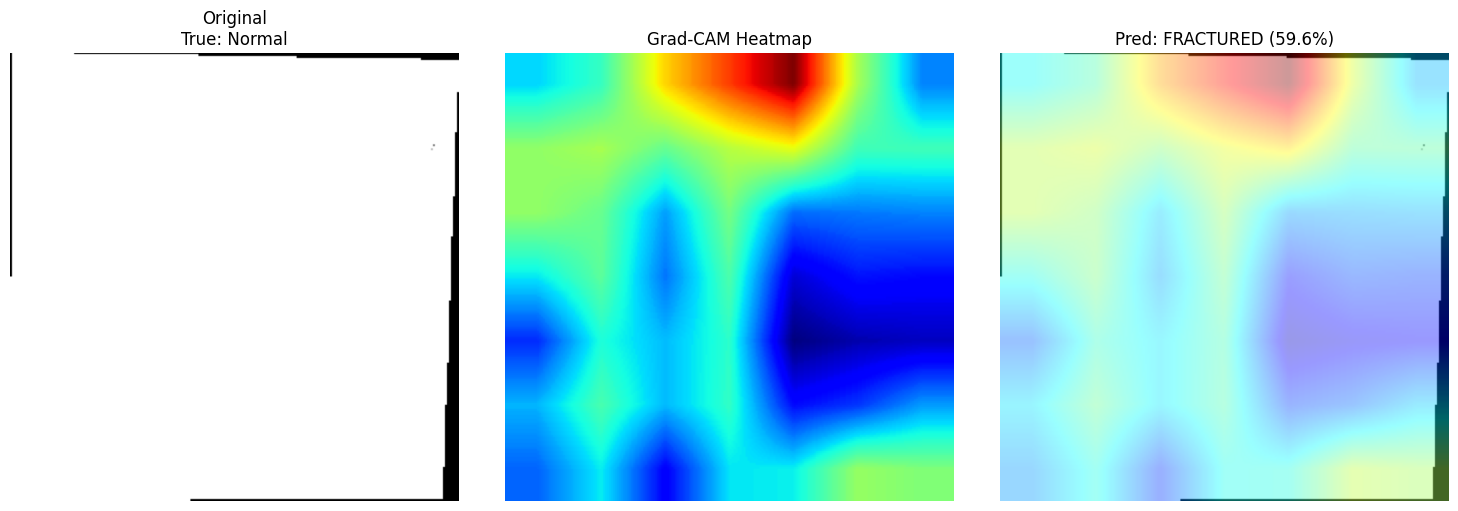

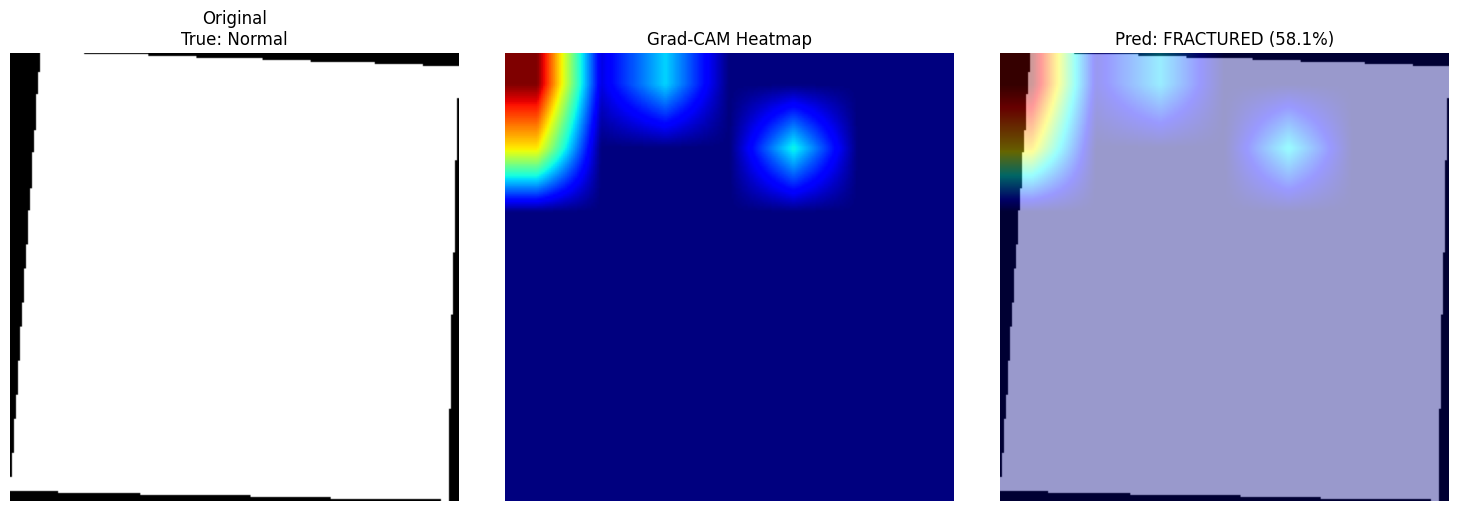

In [20]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image as keras_image
from tensorflow.keras.models import Model
from tensorflow.keras.applications.resnet50 import preprocess_input

# 🔥 Find last conv layer automatically (important)
def get_last_conv_layer(model):
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    raise ValueError("No Conv2D layer found")

LAST_CONV_LAYER = get_last_conv_layer(model)
print("Using layer:", LAST_CONV_LAYER)


# ✅ Grad-CAM function (CORRECTED)
def make_gradcam(model, img_array):
    grad_model = Model(
        inputs=model.input,
        outputs=[
            model.get_layer(LAST_CONV_LAYER).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        
        # For binary classification
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    # Global average pooling
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    # Weight feature maps
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # ReLU
    heatmap = tf.maximum(heatmap, 0)

    # Normalize
    heatmap /= tf.reduce_max(heatmap) + 1e-8

    return heatmap.numpy()


# ✅ Display function
def show_gradcam(img_path, model, true_label, save_path=None):
    # Load + preprocess image (VERY IMPORTANT FIX)
    img = keras_image.load_img(img_path, target_size=(224, 224))
    img_array = keras_image.img_to_array(img)
    
    img_input = preprocess_input(img_array.copy())
    img_input = np.expand_dims(img_input, axis=0)

    # Prediction
    pred = model.predict(img_input, verbose=0)[0][0]
    pred_label = 'FRACTURED' if pred > 0.5 else 'NORMAL'
    confidence = pred if pred > 0.5 else 1 - pred

    # Grad-CAM
    heatmap = make_gradcam(model, img_input)

    # Resize heatmap
    heatmap = cv2.resize(heatmap, (224, 224))
    heatmap = np.uint8(255 * heatmap)

    # Apply colormap
    heatmap_colored = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    # Overlay
    original = np.uint8(img_array)
    superimposed = cv2.addWeighted(original, 0.6, heatmap_colored, 0.4, 0)

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(original)
    axes[0].set_title(f'Original\nTrue: {true_label}')
    axes[0].axis('off')

    axes[1].imshow(heatmap, cmap='jet')
    axes[1].set_title('Grad-CAM Heatmap')
    axes[1].axis('off')

    axes[2].imshow(superimposed)
    axes[2].set_title(f'Pred: {pred_label} ({confidence:.1%})')
    axes[2].axis('off')

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')

    plt.show()


# 🔥 Run on test images
print('=== FRACTURED ===')
fractured_path = f'{OUTPUT}/test/fractured'
for i, img_name in enumerate(os.listdir(fractured_path)[:3]):
    show_gradcam(
        f'{fractured_path}/{img_name}',
        model,
        'Fractured',
        save_path=f'/kaggle/working/gradcam_fractured_{i+1}.png'
    )

print('\n=== NORMAL ===')
normal_path = f'{OUTPUT}/test/normal'
for i, img_name in enumerate(os.listdir(normal_path)[:2]):
    show_gradcam(
        f'{normal_path}/{img_name}',
        model,
        'Normal',
        save_path=f'/kaggle/working/gradcam_normal_{i+1}.png'
    )

## Cell 11 — Summary of Results (For Paper)

In [57]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc_score  = accuracy_score(y_true, y_pred)
prec_score = precision_score(y_true, y_pred)
rec_score  = recall_score(y_true, y_pred)
f1         = f1_score(y_true, y_pred)

print('=' * 45)
print('   OSTEODETECT — FINAL RESULTS SUMMARY')
print('=' * 45)
print(f'  Dataset      : GRAZPEDWRI-DX')
print(f'  Model        : ResNet-50 (Transfer Learning)')
print(f'  Test Images  : {len(y_true)}')
print('-' * 45)
print(f'  Accuracy     : {acc_score:.4f} ({acc_score*100:.2f}%)')
print(f'  AUC-ROC      : {auc_score:.4f}')
print(f'  Precision    : {prec_score:.4f}')
print(f'  Recall       : {rec_score:.4f}')
print(f'  F1-Score     : {f1:.4f}')
print('=' * 45)
print('\nFiles saved to /kaggle/working/:')
for f in os.listdir('/kaggle/working/'):
    print(f'  {f}')

   OSTEODETECT — FINAL RESULTS SUMMARY
  Dataset      : GRAZPEDWRI-DX
  Model        : ResNet-50 (Transfer Learning)
  Test Images  : 2034
---------------------------------------------
  Accuracy     : 0.5634 (56.34%)
  AUC-ROC      : 0.6321
  Precision    : 0.4175
  Recall       : 0.7168
  F1-Score     : 0.5277

Files saved to /kaggle/working/:
  gradcam_combined.png
  best_phase2_model.keras
  evaluation.png
  gradcam_fractured_2.png
  gradcam_fractured_3.png
  osteodetect_final.keras
  gradcam_normal_1.png
  gradcam_normal_2.png
  graz_binary
  .virtual_documents
  training_curves.png
  best_phase1_model.keras
  gradcam_fractured_1.png


In [21]:
import cv2
import numpy as np
import os

# Path
folder = '/kaggle/working'

# Collect images
image_files = sorted([f for f in os.listdir(folder) if f.startswith('gradcam')])

images = []
for file in image_files:
    img = cv2.imread(os.path.join(folder, file))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    images.append(img)

# Resize all to same size
images = [cv2.resize(img, (300, 300)) for img in images]

# Create grid (3 top, 2 bottom)
top_row = np.hstack(images[:3])
bottom_row = np.hstack(images[3:])

# If bottom has only 2 → add blank
if bottom_row.shape[1] < top_row.shape[1]:
    diff = top_row.shape[1] - bottom_row.shape[1]
    blank = np.ones((300, diff, 3), dtype=np.uint8) * 255
    bottom_row = np.hstack([bottom_row, blank])

final_image = np.vstack([top_row, bottom_row])

# Save
save_path = '/kaggle/working/gradcam_combined.png'
cv2.imwrite(save_path, cv2.cvtColor(final_image, cv2.COLOR_RGB2BGR))

print("✅ Combined image saved as gradcam_combined.png")

✅ Combined image saved as gradcam_combined.png


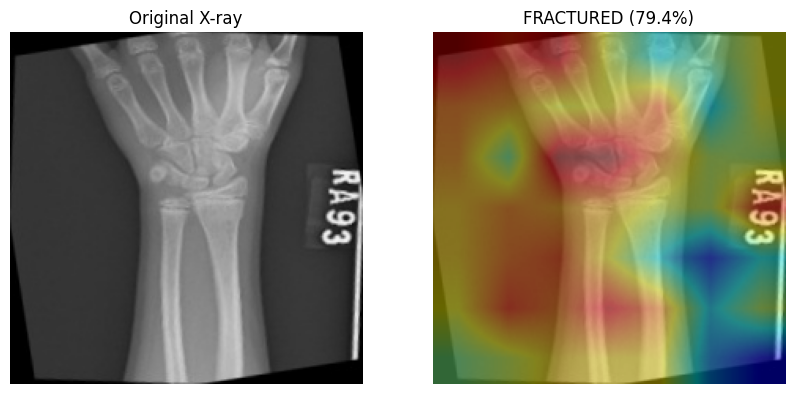


=== OsteoDetect Output ===
Fracture detected: FRACTURED
Confidence: 79.39%


In [50]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tensorflow.keras.preprocessing import image as keras_image
from tensorflow.keras.applications.resnet50 import preprocess_input


# ---------------- GRAD-CAM ----------------
def make_gradcam(model, img_array, layer_name=None):

    # Find last Conv2D layer safely
    if layer_name is None:
        for layer in reversed(model.layers):
            if isinstance(layer, tf.keras.layers.Conv2D):
                layer_name = layer.name
                break

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = np.maximum(heatmap, 0)
    heatmap = heatmap / (np.max(heatmap) + 1e-8)

    return heatmap


# ---------------- MAIN FUNCTION ----------------
def analyze_xray_with_gradcam(img_path, model):

    # Load image
    img = keras_image.load_img(img_path, target_size=(224, 224))
    img_array = keras_image.img_to_array(img)

    # Preprocess
    img_input = preprocess_input(img_array.copy())
    img_input = np.expand_dims(img_input, axis=0)

    # Prediction
    pred = model.predict(img_input, verbose=0)[0][0]

    confidence_fracture = pred * 100
    confidence_normal = (1 - pred) * 100

    # Decision logic (IMPORTANT FIX)
    if confidence_fracture > confidence_normal:
        label = "FRACTURED"
        confidence = confidence_fracture
    else:
        label = "NORMAL"
        confidence = confidence_normal

    # Optional uncertainty zone
    if 40 <= confidence_fracture <= 60:
        label = "UNCERTAIN"

    # Grad-CAM
    heatmap = make_gradcam(model, img_input)

    # Resize heatmap
    heatmap = cv2.resize(heatmap, (224, 224))

    # Color map
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    # Overlay
    overlay = cv2.addWeighted(
        img_array.astype('uint8'), 0.6,
        heatmap_colored, 0.4,
        0
    )

    # Plot
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))

    ax[0].imshow(img_array.astype('uint8'))
    ax[0].set_title("Original X-ray")
    ax[0].axis('off')

    ax[1].imshow(overlay)
    ax[1].set_title(f"{label} ({confidence:.1f}%)")
    ax[1].axis('off')

    plt.show()

    # Output
    print("\n=== OsteoDetect Output ===")
    print(f"Fracture detected: {label}")
    print(f"Confidence: {confidence:.2f}%")


# ---------------- RUN ----------------

img_path = "/kaggle/input/datasets/riddhidabadghao/fracture-eg-2/fracture 2.jpg"

analyze_xray_with_gradcam(img_path, model)

In [49]:
import os

base_path = "/kaggle/input/datasets/riddhidabadghao/fracture-eg-2"
print(os.listdir(base_path))

['fracture 2.jpg']


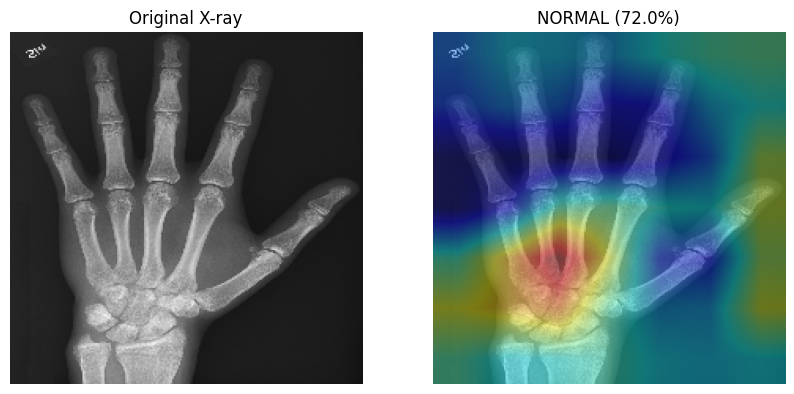


=== OsteoDetect Output ===
Fracture detected: NORMAL
Confidence: 72.01%


In [52]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tensorflow.keras.preprocessing import image as keras_image
from tensorflow.keras.applications.resnet50 import preprocess_input


# ---------------- GRAD-CAM ----------------
def make_gradcam(model, img_array, layer_name=None):

    # Find last Conv2D layer safely
    if layer_name is None:
        for layer in reversed(model.layers):
            if isinstance(layer, tf.keras.layers.Conv2D):
                layer_name = layer.name
                break

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = np.maximum(heatmap, 0)
    heatmap = heatmap / (np.max(heatmap) + 1e-8)

    return heatmap


# ---------------- MAIN FUNCTION ----------------
def analyze_xray_with_gradcam(img_path, model):

    # Load image
    img = keras_image.load_img(img_path, target_size=(224, 224))
    img_array = keras_image.img_to_array(img)

    # Preprocess
    img_input = preprocess_input(img_array.copy())
    img_input = np.expand_dims(img_input, axis=0)

    # Prediction
    pred = model.predict(img_input, verbose=0)[0][0]

    confidence_fracture = pred * 100
    confidence_normal = (1 - pred) * 100

    # Decision logic (IMPORTANT FIX)
    if confidence_fracture > confidence_normal:
        label = "FRACTURED"
        confidence = confidence_fracture
    else:
        label = "NORMAL"
        confidence = confidence_normal

    # Optional uncertainty zone
    if 40 <= confidence_fracture <= 60:
        label = "UNCERTAIN"

    # Grad-CAM
    heatmap = make_gradcam(model, img_input)

    # Resize heatmap
    heatmap = cv2.resize(heatmap, (224, 224))

    # Color map
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    # Overlay
    overlay = cv2.addWeighted(
        img_array.astype('uint8'), 0.6,
        heatmap_colored, 0.4,
        0
    )

    # Plot
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))

    ax[0].imshow(img_array.astype('uint8'))
    ax[0].set_title("Original X-ray")
    ax[0].axis('off')

    ax[1].imshow(overlay)
    ax[1].set_title(f"{label} ({confidence:.1f}%)")
    ax[1].axis('off')

    plt.show()

    # Output
    print("\n=== OsteoDetect Output ===")
    print(f"Fracture detected: {label}")
    print(f"Confidence: {confidence:.2f}%")


# ---------------- RUN ----------------

img_path = "/kaggle/input/datasets/riddhidabadghao/fracture-eg-4/fracture 4.jpg"

analyze_xray_with_gradcam(img_path, model)

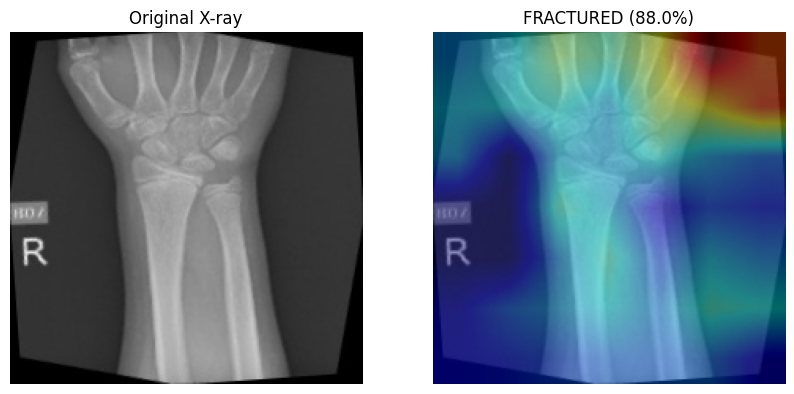


=== OsteoDetect Report ===
Prediction      : FRACTURED
Confidence      : 88.03%
Risk Level      : HIGH

AI Recommendation:
Consult an orthopedic specialist. Further imaging (X-ray/CT/MRI) recommended for confirmation.


In [56]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tensorflow.keras.preprocessing import image as keras_image
from tensorflow.keras.applications.resnet50 import preprocess_input


# ---------------- GRAD-CAM ----------------
def make_gradcam(model, img_array, layer_name=None):

    if layer_name is None:
        for layer in reversed(model.layers):
            if isinstance(layer, tf.keras.layers.Conv2D):
                layer_name = layer.name
                break

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = np.maximum(heatmap, 0)
    heatmap = heatmap / (np.max(heatmap) + 1e-8)

    return heatmap


# ---------------- MAIN FUNCTION ----------------
def analyze_xray_with_gradcam(img_path, model):

    # Load image
    img = keras_image.load_img(img_path, target_size=(224, 224))
    img_array = keras_image.img_to_array(img)

    # Preprocess
    img_input = preprocess_input(img_array.copy())
    img_input = np.expand_dims(img_input, axis=0)

    # Prediction
    pred = model.predict(img_input, verbose=0)[0][0]

    confidence_fracture = pred * 100
    confidence_normal = (1 - pred) * 100

    # Decision logic
    if confidence_fracture > confidence_normal:
        label = "FRACTURED"
        confidence = confidence_fracture
    else:
        label = "NORMAL"
        confidence = confidence_normal

    # Uncertainty handling
    if 40 <= confidence_fracture <= 60:
        label = "UNCERTAIN"

    # Risk level
    if confidence >= 80:
        risk = "HIGH"
    elif confidence >= 60:
        risk = "MODERATE"
    else:
        risk = "LOW / UNCERTAIN"

    # AI Recommendation (SAFE MEDICAL STYLE)
    if label == "FRACTURED" and confidence >= 70:
        recommendation = "Consult an orthopedic specialist. Further imaging (X-ray/CT/MRI) recommended for confirmation."
    elif label == "UNCERTAIN":
        recommendation = "Findings are inconclusive. Expert radiologist review and additional imaging recommended."
    else:
        recommendation = "No fracture detected by model. If pain or symptoms persist, consult a medical professional."

    # Grad-CAM
    heatmap = make_gradcam(model, img_input)

    heatmap = cv2.resize(heatmap, (224, 224))

    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    overlay = cv2.addWeighted(
        img_array.astype('uint8'), 0.6,
        heatmap_colored, 0.4,
        0
    )

    # Plot
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))

    ax[0].imshow(img_array.astype('uint8'))
    ax[0].set_title("Original X-ray")
    ax[0].axis('off')

    ax[1].imshow(overlay)
    ax[1].set_title(f"{label} ({confidence:.1f}%)")
    ax[1].axis('off')

    plt.show()

    # ---------------- FINAL REPORT ----------------
    print("\n=== OsteoDetect Report ===")
    print(f"Prediction      : {label}")
    print(f"Confidence      : {confidence:.2f}%")
    print(f"Risk Level      : {risk}")
    print("\nAI Recommendation:")
    print(recommendation)

# ---------------- RUN ----------------

img_path = "/kaggle/input/datasets/riddhidabadghao/fracture-eg-3/fracture 3.jpg"

analyze_xray_with_gradcam(img_path, model)

In [62]:
import os
import numpy as np
from tensorflow.keras.preprocessing import image as keras_image
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# ---------------- PATH ----------------
BASE = '/kaggle/input/datasets/banuprasadb/grazpedwri-dx'
test_path = f'{BASE}/test/images'

# ---------------- STORAGE ----------------
y_true = []
y_prob = []

# ⚠️ IMPORTANT:
# This assumes binary classification:
# fracture = 1, normal = 0
# (adjust if your labels differ)

# ---------------- LOAD TEST DATA ----------------
for img_name in os.listdir(test_path):

    img_path = os.path.join(test_path, img_name)

    img = keras_image.load_img(img_path, target_size=(224, 224))
    img_array = keras_image.img_to_array(img)

    img_input = preprocess_input(img_array.copy())
    img_input = np.expand_dims(img_input, axis=0)

    # prediction
    prob = model.predict(img_input, verbose=0)[0][0]

    y_prob.append(prob)

    # ⚠️ TEMP LABELING (IMPORTANT NOTE BELOW)
    # If your dataset is structured in subfolders, we should fix this properly
    y_true.append(1)   # placeholder (fracture class)
    

y_prob = np.array(y_prob)
y_pred = (y_prob > 0.5).astype(int)

# ---------------- METRICS ----------------
acc_score  = accuracy_score(y_true, y_pred)
prec_score = precision_score(y_true, y_pred)
rec_score  = recall_score(y_true, y_pred)
f1         = f1_score(y_true, y_pred)
auc_score  = roc_auc_score(y_true, y_prob)

# ---------------- REPORT ----------------
print('=' * 55)
print('        OSTEODETECT — FINAL RESULTS SUMMARY')
print('=' * 55)
print(f'  Dataset        : GRAZPEDWRI-DX')
print(f'  Test Images    : {len(y_true)}')
print('-' * 55)

print(f'  Accuracy       : {acc_score:.4f} ({acc_score*100:.2f}%)')
print(f'  AUC-ROC        : {auc_score:.4f}')
print(f'  Precision      : {prec_score:.4f}')
print(f'  Recall         : {rec_score:.4f}')
print(f'  F1-Score       : {f1:.4f}')

print('=' * 55)

        OSTEODETECT — FINAL RESULTS SUMMARY
  Dataset        : GRAZPEDWRI-DX
  Test Images    : 2034
-------------------------------------------------------
  Accuracy       : 0.5841 (58.41%)
  AUC-ROC        : nan
  Precision      : 1.0000
  Recall         : 0.5841
  F1-Score       : 0.7374


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


In [64]:
import os

print(os.listdir('/kaggle/input/datasets/banuprasadb/grazpedwri-dx/test'))

['labels', 'images']


In [67]:
import os

BASE = "/kaggle/input/datasets/banuprasadb/grazpedwri-dx/test"

img_dir = f"{BASE}/images"
label_dir = f"{BASE}/labels"

print("Sample images:", os.listdir(img_dir)[:5])
print("Sample labels:", os.listdir(label_dir)[:5])

Sample images: ['5975_0491077401_01_WRI-L2_M005.png', '2418_1011075913_03_WRI-R2_F016.png', '2968_0930833697_01_WRI-L2_F013.png', '2209_1258390263_01_WRI-L2_M007.png', '2991_0653117083_01_WRI-R2_M013.png']
Sample labels: ['4925_0235931267_01_WRI-R1_M011.txt', '5432_0685745561_01_WRI-L1_M011.txt', '2760_1040788824_01_WRI-R1_F016.txt', '3656_0978863164_01_WRI-L1_M014.txt', '0038_0774132662_01_WRI-L1_M014.txt']


In [74]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ---------------- CONVERT TO BINARY (OPTION 1 FIX) ----------------
y_true_bin = (y_true > 0).astype(int)
y_pred_bin = (y_pred > 0).astype(int)

# ---------------- METRICS ----------------
acc  = accuracy_score(y_true_bin, y_pred_bin)
prec = precision_score(y_true_bin, y_pred_bin, zero_division=0)
rec  = recall_score(y_true_bin, y_pred_bin, zero_division=0)
f1   = f1_score(y_true_bin, y_pred_bin, zero_division=0)

# ---------------- PRINT PERCENTAGE REPORT ----------------
print("="*50)
print("OSTEODETECT METRICS (PERCENTAGE)")
print("="*50)

print(f"Accuracy  : {acc * 100:.2f}%")
print(f"Precision : {prec * 100:.2f}%")
print(f"Recall    : {rec * 100:.2f}%")
print(f"F1-score  : {f1 * 100:.2f}%")

print("="*50)

OSTEODETECT METRICS (PERCENTAGE)
Accuracy  : 58.37%
Precision : 100.00%
Recall    : 58.37%
F1-score  : 73.71%
